# DATASET 1 - Spending on technology per student

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("slfs22_1a.csv", low_memory = False)

locale_map = {
    '11': 'City',   '12': 'City',   '13': 'City',
    '21': 'Suburb', '22': 'Suburb', '23': 'Suburb',
    '31': 'Town',   '32': 'Town',   '33': 'Town',
    '41': 'Rural',  '42': 'Rural',  '43': 'Rural',
}

df['LOCALE'] = df['LOCALE'].astype(str).str.strip()
df['locale_group'] = df['LOCALE'].map(locale_map)
df = df[df['locale_group'].notna() & (df['MEMBER'] >= 10)]

#tech spending
df['total_tech'] = df[['V02S', 'K14S', 'K15S']].sum(axis=1, min_count=1)
df['tech_pp']    = df['total_tech'] / df['MEMBER']
df['exp_pp']     = df['TCURELSCS']  / df['MEMBER']

# filter valid rows 
df_clean = df[
    (df['tech_pp'] > 0) & (df['tech_pp'] < 10000) &
    (df['exp_pp']  > 0) & (df['exp_pp']  < 100000)
].copy()

order = ['City', 'Suburb', 'Town', 'Rural']
rows = []

for locale in order:
    sub = df_clean[df_clean['locale_group'] == locale]['tech_pp']
    all_grp = df[df['locale_group'] == locale]
    pct = (all_grp['tech_pp'] > 0).sum() / len(all_grp) * 100
    
    rows.append({'Locale': locale,
    'Schools (n)': len(sub),
    'Mean Per-Pupil ($)': round(sub.mean(), 2),
    'Median Per-Pupil ($)': round(sub.median(), 2),
    '% Schools Reporting Tech': round(pct, 1)
        })

table = pd.DataFrame(rows)
print("           Summary of spending on Technology across Locales in the United States")
print(table.to_string(index = False))

           Summary of spending on Technology across Locales in the United States
Locale  Schools (n)  Mean Per-Pupil ($)  Median Per-Pupil ($)  % Schools Reporting Tech
  City         7569              239.70                131.72                      29.1
Suburb         8852              182.19                 94.31                      29.6
  Town         5449              239.23                140.50                      45.3
 Rural        12161              268.91                155.84                      46.1


# PLOT 2 - NTIA Internet Use Survey by the National Telecommunications and Information Administration (a federal agency) 


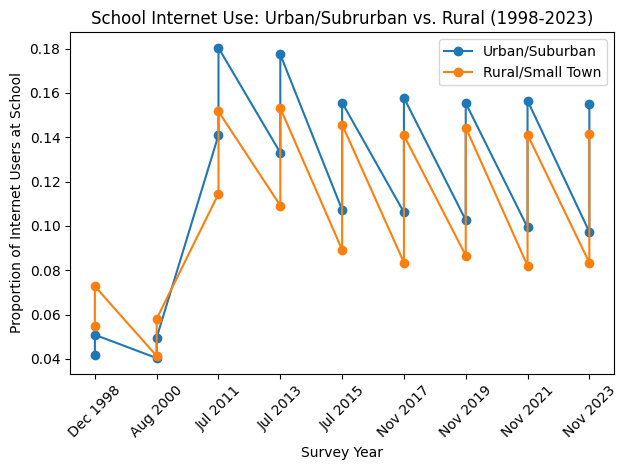

In [87]:
df2 = pd.read_csv('ntia-analyze-table.csv')

school = df2[df2["variable"] == 'schoolInternetUser']

plt.plot(school['dataset'], school['metroYesProp'], label = 'Urban/Suburban', marker = 'o')
plt.plot(school['dataset'], school['metroNoProp'], label = 'Rural/Small Town', marker = 'o')

plt.title('School Internet Use: Urban/Subrurban vs. Rural (1998-2023)')
plt.xlabel('Survey Year')
plt.ylabel('Proportion of Internet Users at School')

plt.xticks(rotation = 45)
plt.legend()
plt.tight_layout()

# PLOT 3 - Washington State School Building Technology Survey 

Text(0, 0.5, 'Number of Schools')

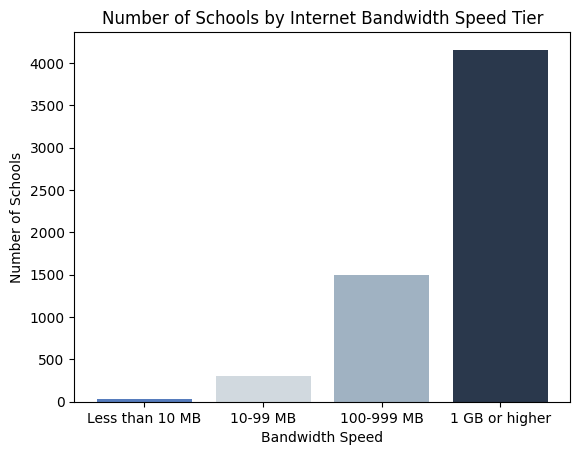

In [80]:
df3 = pd.read_csv('School_Building_Technology_Survey.csv')

speed_cols = ['Less than 10 MB', '10-99 MB', '100-999 MB', '1 GB or higher']
speed_counts = df3[speed_cols].sum()

plt.bar(speed_counts.index, speed_counts.values, color=['#567CBD','#D1D9DF','#A0B2C2','#2A384C'])
plt.title('Number of Schools by Internet Bandwidth Speed Tier')
plt.xlabel('Bandwidth Speed')
plt.ylabel('Number of Schools')